# Matplotlib: From Data to Insight
### A hands-on guide using real Travel Package data

**Dataset:** Travel Package Purchase Prediction (~4,888 customers)  
**Central question we'll answer visually: *Who buys travel packages?***

---

## Part 0 — Setup & Dataset Walkthrough

Before we plot anything, let's understand what we're working with.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Travel.csv')

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 4888, Columns: 20


,m,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [5]:
print("Key stats:")
print(f"  Customers who bought a package : {df['ProdTaken'].sum()} ({df['ProdTaken'].mean()*100:.1f}%)")
print(f"  Age range                      : {df['Age'].min():.0f} – {df['Age'].max():.0f}")
print(f"  Monthly income range           : {df['MonthlyIncome'].min():,} – {df['MonthlyIncome'].max():,}")
print(f"  Occupations                    : {df['Occupation'].dropna().unique().tolist()}")
print(f"  Products pitched               : {df['ProductPitched'].dropna().unique().tolist()}")

Key stats:
  Customers who bought a package : 920 (18.8%)
  Age range                      : 18 – 61
  Monthly income range           : 1,000.0 – 98,678.0
  Occupations                    : ['Salaried', 'Free Lancer', 'Small Business', 'Large Business']
  Products pitched               : ['Deluxe', 'Basic', 'Standard', 'Super Deluxe', 'King']


---
## Part 1 — pyplot basics (`plt`)

We'll use `matplotlib.pyplot` — imported as `plt` by convention.  
The pattern is always: **prepare data → call plot function → customize → show**.

Let's answer real questions about our dataset using four chart types.

### 1.1 — Line Plot
**Question: Does average income increase with age?**

A line plot shows how one variable changes with respect to another.  
We group customers by age and plot the average income at each age.

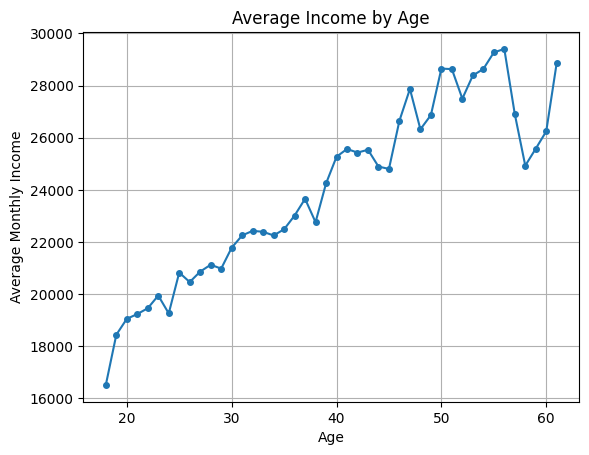

In [6]:
age_income = df.groupby('Age')['MonthlyIncome'].mean()

plt.plot(age_income.index, age_income.values, marker='o', markersize=4)

plt.title('Average Income by Age')
plt.xlabel('Age')
plt.ylabel('Average Monthly Income')
plt.grid(True)
plt.show()

### 1.2 — Bar Chart
**Question: Which travel product gets pitched most often?**

Bar charts are best for comparing quantities across discrete categories.

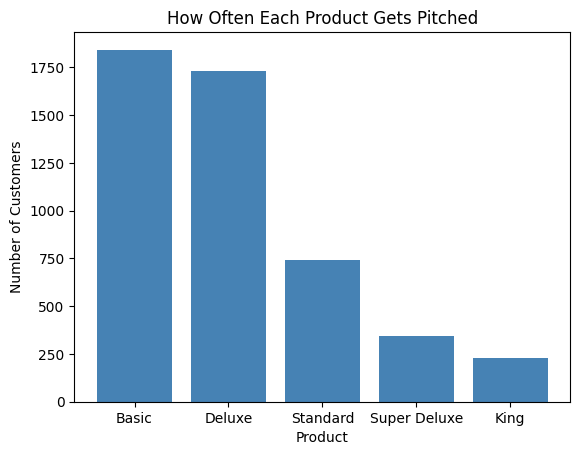

In [7]:
product_counts = df['ProductPitched'].value_counts()

plt.bar(product_counts.index, product_counts.values, color='steelblue')

plt.title('How Often Each Product Gets Pitched')
plt.xlabel('Product')
plt.ylabel('Number of Customers')
plt.show()

### 1.3 — Pie Chart
**Question: What is the occupation breakdown of our customer base?**

Pie charts show proportions. They work well with 3–4 categories. Beyond that, they get hard to read — we'll see why shortly.

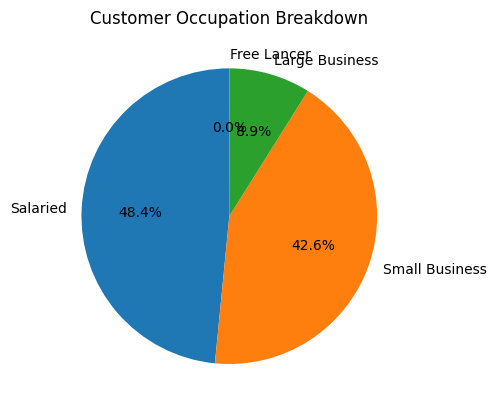

In [8]:
occupation_counts = df['Occupation'].value_counts()

plt.pie(
    occupation_counts.values,
    labels=occupation_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Occupation Breakdown')
plt.show()

>  **Note:** With 4 categories this is readable. Try it with `Designation` (5 categories) and notice how it starts to get cluttered. For many categories, a bar chart is almost always clearer.

### 1.4 — Scatter Plot
**Question: Is there a relationship between age, income, and who actually buys a package?**

Scatter plots reveal relationships between two numerical variables. We can encode a third variable using colour.

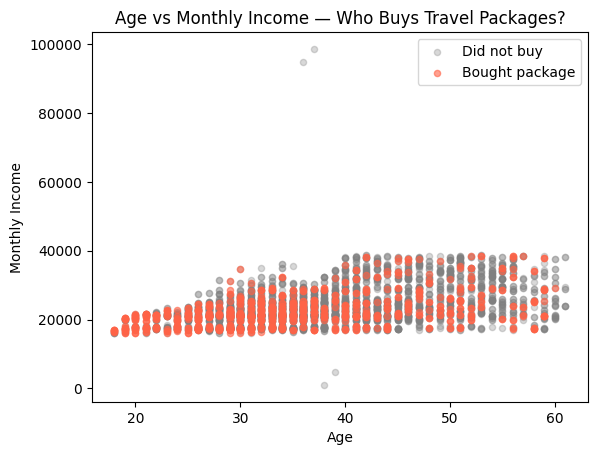

In [9]:
buyers     = df[df['ProdTaken'] == 1]
non_buyers = df[df['ProdTaken'] == 0]

plt.scatter(non_buyers['Age'], non_buyers['MonthlyIncome'],
            alpha=0.3, label='Did not buy', color='gray', s=20)
plt.scatter(buyers['Age'], buyers['MonthlyIncome'],
            alpha=0.6, label='Bought package', color='tomato', s=20)

plt.title('Age vs Monthly Income — Who Buys Travel Packages?')
plt.xlabel('Age')
plt.ylabel('Monthly Income')
plt.legend()
plt.show()

> 💡 **Notice:** Buyers aren't concentrated in any single age/income band — which tells us these two features alone won't predict purchasing. That's already a data insight, just from a scatter plot.

### 1.5 — Histogram

A histogram splits a numerical variable into equal-width **bins** and counts how many values fall in each bin. It shows you the *shape* of a distribution — is it symmetric? skewed? does it have multiple peaks?

We also overlay a **KDE curve** (Kernel Density Estimate) — a smoothed version of the histogram that makes the shape easier to read.

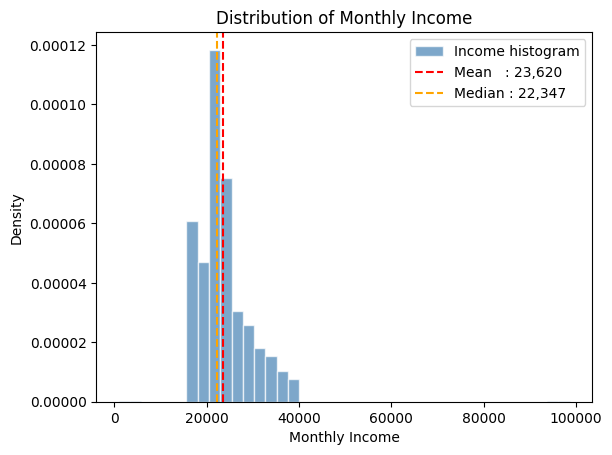

In [10]:
income = df['MonthlyIncome'].dropna()

# The histogram — counts per bin
plt.hist(income, bins=40, color='steelblue', edgecolor='white',
         density=True, alpha=0.7, label='Income histogram')


# Mark the mean and median
plt.axvline(income.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean   : {income.mean():,.0f}')
plt.axvline(income.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median : {income.median():,.0f}')

plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Density')
plt.legend()
plt.show()

### 2 — Boxplot

A boxplot compresses an entire distribution into 5 numbers: **min whisker, Q1, median, Q3, max whisker** — plus any outliers as dots. This makes it very easy to compare groups side by side.

```
         |----[  Q1 | median | Q3  ]----|
       whisker   box (IQR)          whisker    • outlier
```

/tmp/ipykernel_2194/965594932.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


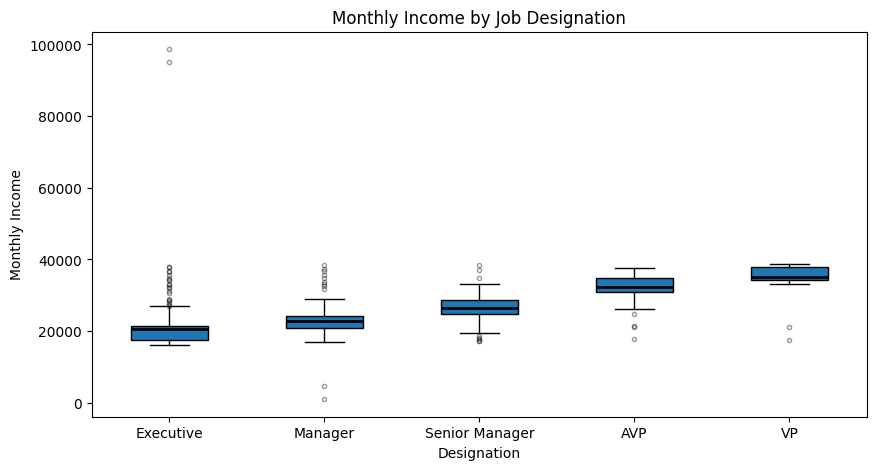

In [11]:
designation_order = ['Executive', 'Manager', 'Senior Manager', 'AVP', 'VP']

income_by_designation = [
    df[df['Designation'] == d]['MonthlyIncome'].dropna().values
    for d in designation_order
]

plt.figure(figsize=(10, 5))
plt.boxplot(
    income_by_designation,
    labels=designation_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)   # style the outlier dots
)

plt.title('Monthly Income by Job Designation')
plt.xlabel('Designation')
plt.ylabel('Monthly Income')
plt.show()

>  **Discussion:**
> - The histogram showed us the *overall shape* of income - useful for understanding the whole population.
> - The boxplot shows us *how groups compare* - you can immediately see that VP income has a higher median and tighter spread than Executive.
>
> Which would you use to explain income inequality between designations to your manager? Which would you use to check if income is normally distributed before running a statistical test?

---
## Part 3 — The Problem with `plt` (and why `fig, ax` exists)

So far `plt` has worked fine — one plot per cell, simple and clean.

But `plt` has a hidden design flaw: **it maintains a single global active figure.** Every `plt.something()` call goes to whatever figure is currently "active". This works fine when you have one plot. It silently breaks when you have more than one.

Let's see the failure happen.

### 3.1 — The Problem: `plt` draws on the wrong figure

Imagine you have a helper function that plots income distribution. You call it twice — once for buyers, once for non-buyers — expecting two separate figures.

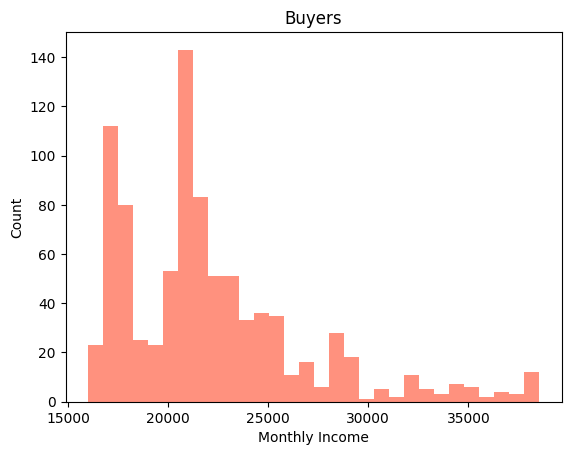

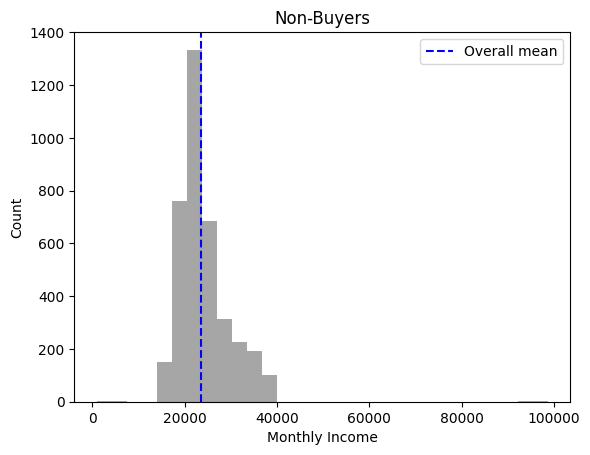

In [12]:
def plot_income(group, color, title):

    plt.figure()                              # creates a new figure... or does it?
    plt.hist(group['MonthlyIncome'].dropna(), bins=30, color=color, alpha=0.7)
    plt.title(title)
    plt.xlabel('Monthly Income')
    plt.ylabel('Count')

buyers     = df[df['ProdTaken'] == 1]
non_buyers = df[df['ProdTaken'] == 0]

plot_income(buyers,     'tomato', 'Buyers')
plot_income(non_buyers, 'gray',   'Non-Buyers')

# Add vertical line - only goes to current active figure
plt.axvline(df['MonthlyIncome'].mean(), color='blue', linestyle='--', label='Overall mean')
plt.legend()

plt.show()

>  **What went wrong?** The mean line was supposed to go on the Non-Buyers figure, but `plt` drew it on whichever figure was internally "active" — which you can't see or control. No error was raised. The plot looks plausible. This is the dangerous kind of bug.
>
> With `plt`, you can't *target* a specific figure. You just fire commands and hope the state machine is pointing at the right place.

### 3.2 — The Fix: Object-Oriented matplotlib with `fig, ax`

`plt.subplots()` returns two objects:
- **`fig`** — the entire figure (canvas). Controls size, saving, overall title.
- **`ax`** — an axes object. This is the actual plot. You call methods *on it* directly.

No global state. No guessing. Each plot is a variable you hold.

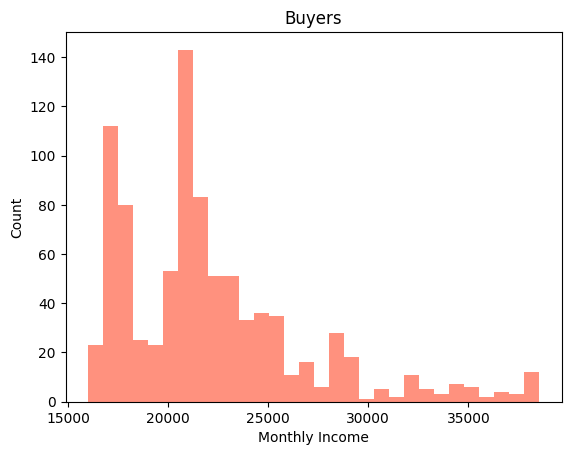

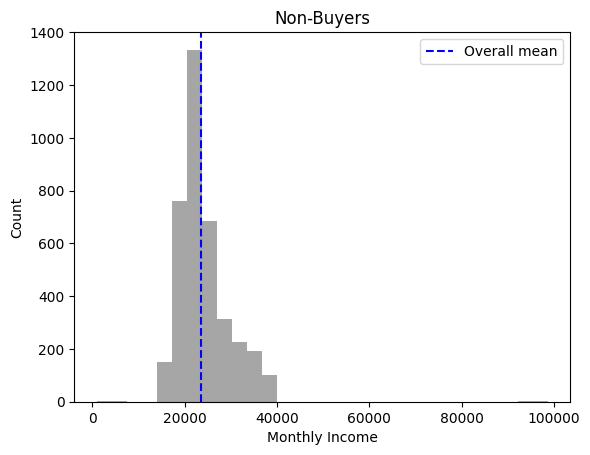

In [13]:
def plot_income_oo(ax, group, color, title):

    ax.hist(group['MonthlyIncome'].dropna(), bins=30, color=color, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Monthly Income')
    ax.set_ylabel('Count')

# Create two figures explicitly — each is a named Python object
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

plot_income_oo(ax1, buyers,     'tomato', 'Buyers')
plot_income_oo(ax2, non_buyers, 'gray',   'Non-Buyers')

# Now add the mean line — we target ax2 explicitly, no ambiguity
ax2.axvline(df['MonthlyIncome'].mean(), color='blue', linestyle='--', label='Overall mean')
ax2.legend()

plt.show()

>  **What's different?** We pass `ax2` explicitly, so the mean line goes exactly where we intended — always, regardless of execution order. The function doesn't touch any global state.
>
> This is the core reason `fig, ax` exists: **predictability**. You're in control of every element.

### 3.3 — Building a dashboard: the `fig, ax` way

Now let's use `plt.subplots()` to build a proper 2×2 dashboard. Each subplot is a named variable — you can modify any of them at any time, in any order.

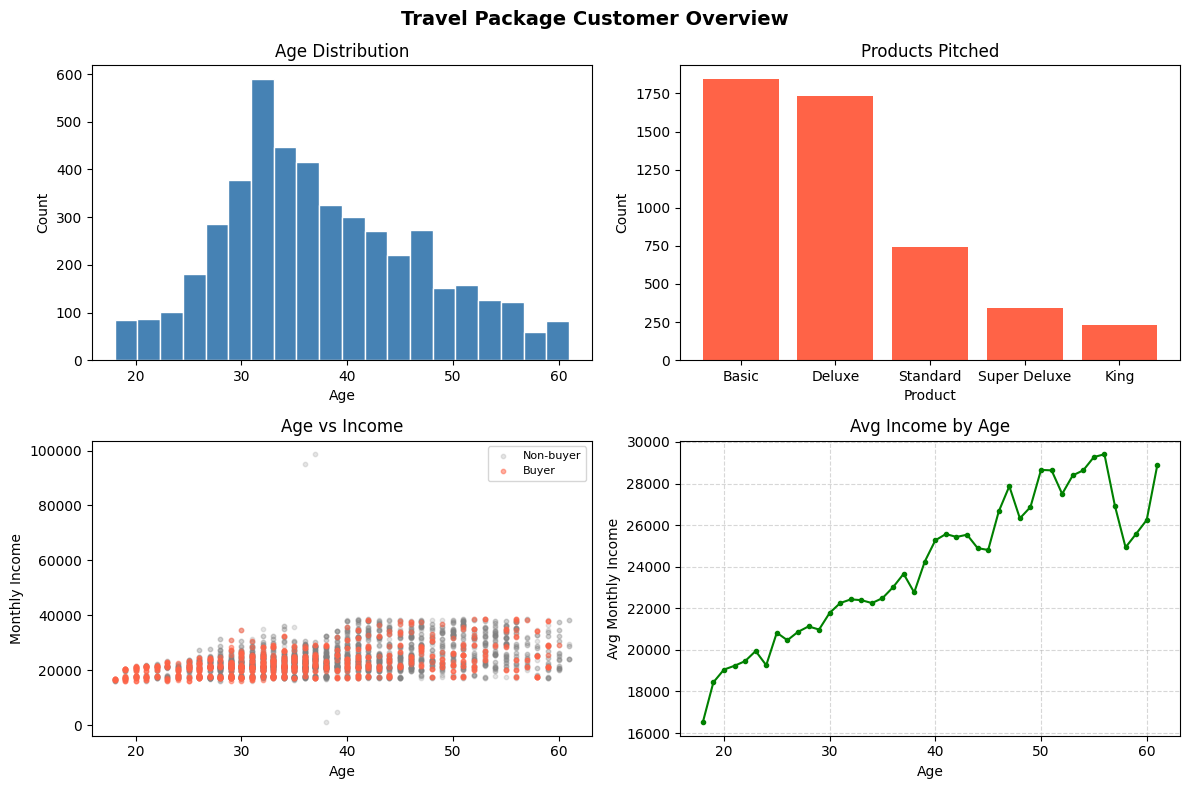

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Give each subplot a clear name — no index juggling
ax_age, ax_product, ax_scatter, ax_income = axes.flatten()

# Plot 1: Age distribution
ax_age.hist(df['Age'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax_age.set_title('Age Distribution')
ax_age.set_xlabel('Age')
ax_age.set_ylabel('Count')

# Plot 2: Products pitched
product_counts = df['ProductPitched'].value_counts()
ax_product.bar(product_counts.index, product_counts.values, color='tomato')
ax_product.set_title('Products Pitched')
ax_product.set_xlabel('Product')
ax_product.set_ylabel('Count')

# Plot 3: Age vs Income scatter
ax_scatter.scatter(non_buyers['Age'], non_buyers['MonthlyIncome'], alpha=0.2, s=10, color='gray',  label='Non-buyer')
ax_scatter.scatter(buyers['Age'],     buyers['MonthlyIncome'],     alpha=0.5, s=10, color='tomato', label='Buyer')
ax_scatter.set_title('Age vs Income')
ax_scatter.set_xlabel('Age')
ax_scatter.set_ylabel('Monthly Income')
ax_scatter.legend(fontsize=8)

# Plot 4: Average income by age (line)
age_income = df.groupby('Age')['MonthlyIncome'].mean()
ax_income.plot(age_income.index, age_income.values, color='green', marker='o', markersize=3)
ax_income.set_title('Avg Income by Age')
ax_income.set_xlabel('Age')
ax_income.set_ylabel('Avg Monthly Income')
ax_income.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Travel Package Customer Overview', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

> **Key advantage:** Each subplot (`ax_age`, `ax_product`, etc.) is a real Python object. You can modify any of them after the fact, pass them into functions, loop over them, or share their axes with `sharex=True` / `sharey=True`.

### 3.4 — The power of `ax` objects: programmatic subplots

Once each plot is an object, you can generate an entire grid of plots with a simple loop. Here we plot income distributions for each occupation — something messy and error-prone with `plt`, trivial with `fig, ax`.

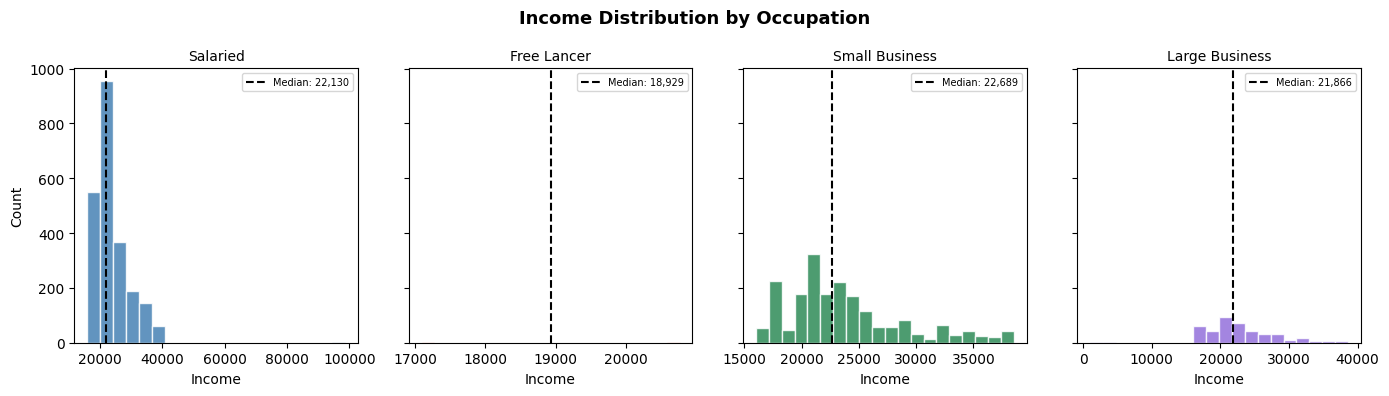

In [15]:
occupations = df['Occupation'].dropna().unique()
colors = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']

fig, axes = plt.subplots(1, len(occupations), figsize=(14, 4), sharey=True)

for ax, occupation, color in zip(axes, occupations, colors):
    income_data = df[df['Occupation'] == occupation]['MonthlyIncome'].dropna()

    ax.hist(income_data, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(occupation, fontsize=10)
    ax.set_xlabel('Income')

    ax.axvline(income_data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {income_data.median():,.0f}')

    ax.legend(fontsize=7)

axes[0].set_ylabel('Count')
fig.suptitle('Income Distribution by Occupation', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

>  `sharey=True` forces all subplots to use the same y-axis scale — making comparisons honest. `zip(axes, occupations, colors)` keeps the loop clean. This same pattern works for 4 subplots or 40.

---
## Part 4 — BONUS 3D Plot

A plot you'd actually put in a report needs clean labels, a consistent style, and the ability to save.

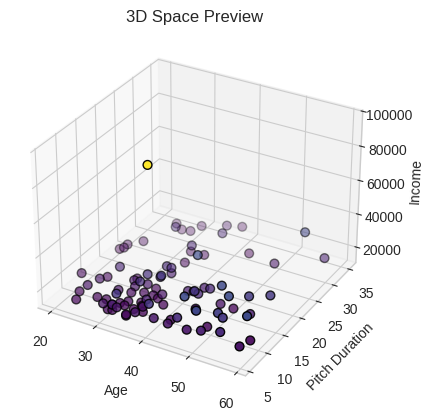

In [17]:
sample = df.dropna(subset=['Age', 'DurationOfPitch', 'MonthlyIncome']).head(100)
x = sample['Age']
y = sample['DurationOfPitch']
z = sample['MonthlyIncome']


ax = plt.axes(projection='3d')

ax.scatter3D(x, y, z, c=z, cmap='viridis', s=40, edgecolors='black')

ax.set_title("3D Space Preview")
ax.set_xlabel("Age")
ax.set_ylabel("Pitch Duration")
ax.set_zlabel("Income")

plt.show()